In [15]:
import os
import sys
import faiss
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- 한글 폰트 적용을 위한 코드 ---------- #
from matplotlib import font_manager

root_dir = "/".join(os.getcwd().split("/")[:-1])
font_path = font_path = Path(root_dir).joinpath("data/NanumGothic-Regular.ttf")
font_name = font_manager.FontProperties(fname=font_path).get_name()
fontprop = font_manager.FontProperties(fname=font_path, size=12)
# ------------------------------------------ #

sys.path.append(os.path.abspath(".."))

from utils.dataset.config import DatasetPath
from utils.dataset.domain import fashion
from utils.dataset.user_generator import generate_users
from utils.dataset.item_generator import generate_items

# Dataset Path
- `recsys/data/dataset/` 하위 경로 생성

In [16]:
# 현재 Jupyter Notebook 실행 경로 (e.g., `documents/recsys/2_dataset`)
current_dir = os.path.abspath(os.curdir)

# `../recsys` 경로
base_dir = "/".join(current_dir.split("/")[:-1])

# 데이터셋 경로
dataset_dir = Path(base_dir).joinpath("data/dataset")

paths = DatasetPath(base_dir=dataset_dir, dataset_name="fashion")

# User Metadata
- 가상의 유저 데이터 생성

In [17]:
# 중앙값 근처로 많이 생성되는 삼각분포(기본)
df_user = generate_users(
    num_users=10000,
    age_range=(18, 60),
    genders=("M", "F"),
    gender_probs=(0.5, 0.5),
    seed=42,
)

# ---------- 피크 나이를 30세로 명시 ---------- #
# df_user_30peak = generate_users(
#     num_users=10000, age_range=(18, 70), age_mode=30, seed=42
# )

# ---------- 기존 균등분포로 생성하고 싶다면 ---------- #
# df_user_uniform = generate_users(
#     num_users=10000, age_range=(18, 70), age_distribution="uniform", seed=42
# )

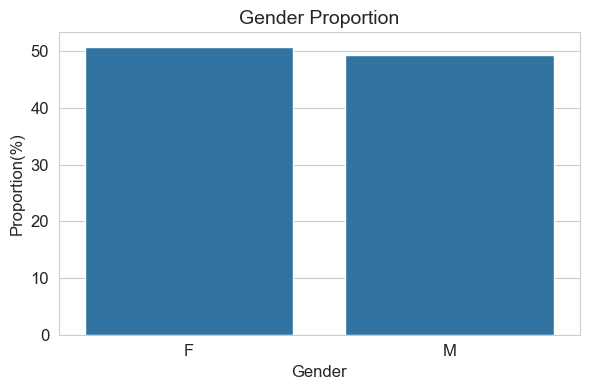

In [18]:
# 성별 분포
df_age_agg = df_user["gender"].value_counts(normalize=True).sort_index().reset_index()
df_age_agg["proportion"] = df_age_agg["proportion"] * 100

plt.figure(figsize=(6, 4), dpi=100)
sns.barplot(data=df_age_agg, x="gender", y="proportion")
plt.title("Gender Proportion", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Proportion(%)", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

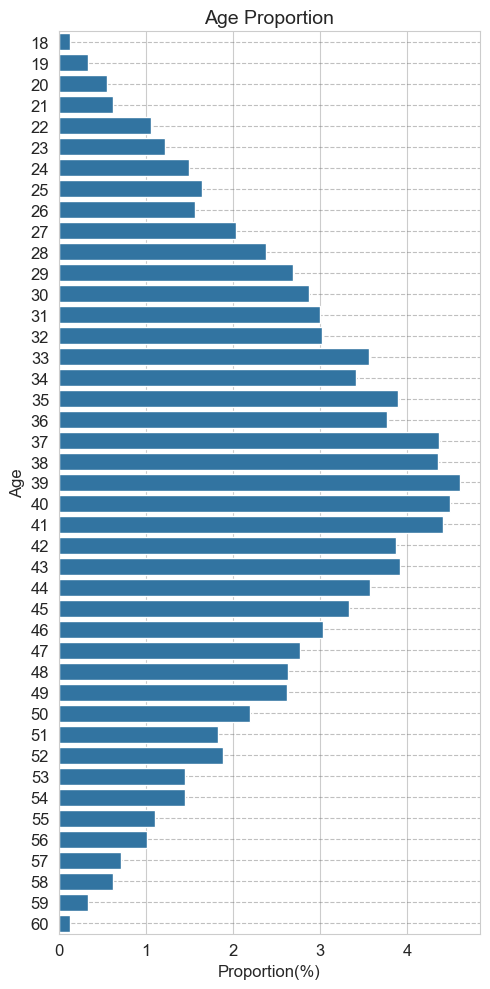

In [19]:
# 연령 분포
df_age_agg = df_user["age"].value_counts(normalize=True).sort_index().reset_index()
df_age_agg["age"] = df_age_agg["age"].astype(str)
df_age_agg["proportion"] = df_age_agg["proportion"] * 100

plt.figure(figsize=(5, 10), dpi=100)
sns.barplot(data=df_age_agg, x="proportion", y="age")
plt.title("Age Proportion", fontsize=14)
plt.xlabel("Proportion(%)", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, axis="y", linestyle="--", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
df_user.to_parquet(paths.user_metadata_path)

# Item Metadata
- 가상의 아이템 데이터 생성

In [21]:
# 아이템 속성 + 이름 템플릿 기반으로 10,000개 생성
df_item = generate_items(fashion.Fashion, num_items=10000)
df_item.head()

,item_id,title,color,style,fit,material,season,sleeve,category
0,1,"트렌디한 캐주얼룩, 오버핏 재킷 in 겨울",와인,캐주얼,오버핏,폴리,겨울,민소매,재킷
1,2,가을 슬림핏 블랙 데님 숏 블라우스,블랙,포멀,슬림핏,데님,가을,숏,블라우스
2,3,필수템! 빈티지 무드의 여름용 티셔츠,베이지,빈티지,세미오버핏,플리스,여름,숏,티셔츠
3,4,간절기 감성 크롭핏 플리스 조거팬츠,민트,미니멀,크롭핏,플리스,간절기,7부,조거팬츠
4,5,빈티지 무드의 올리브 맨투맨,올리브,빈티지,레귤러핏,레이온,간절기,숏슬리브,맨투맨


In [22]:
from dataclasses import fields

# Fashion 클래스에서 `name_templates` 제외한 속성명 리스트
columns = [f.name for f in fields(fashion.Fashion) if f.name != "name_templates"]
print(columns)

['color', 'style', 'fit', 'material', 'season', 'sleeve', 'category']


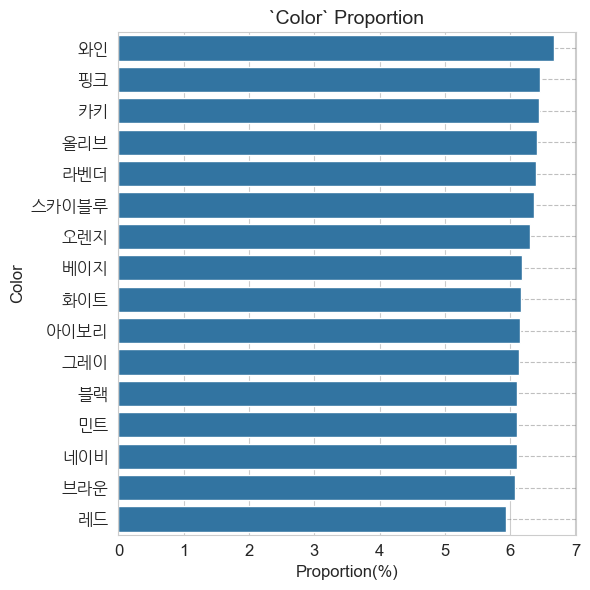

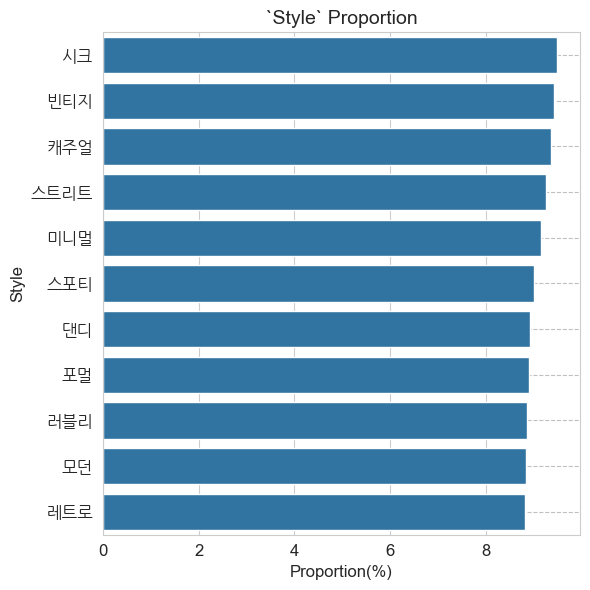

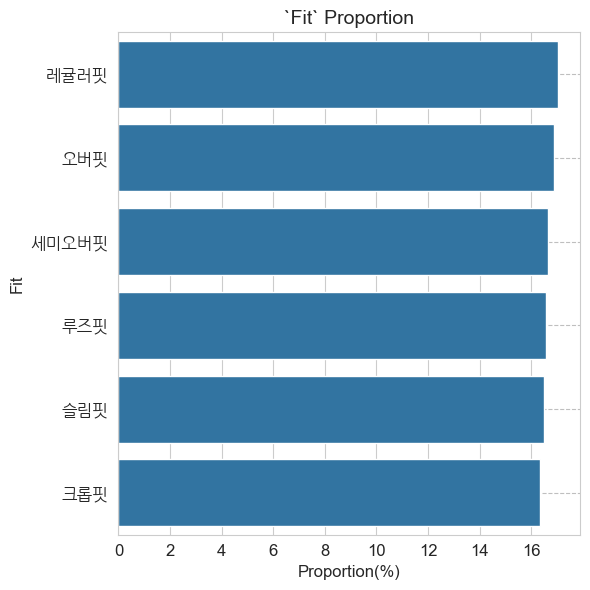

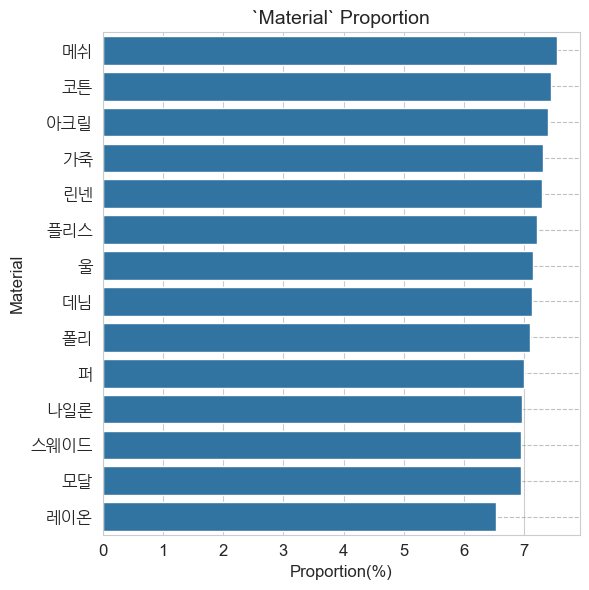

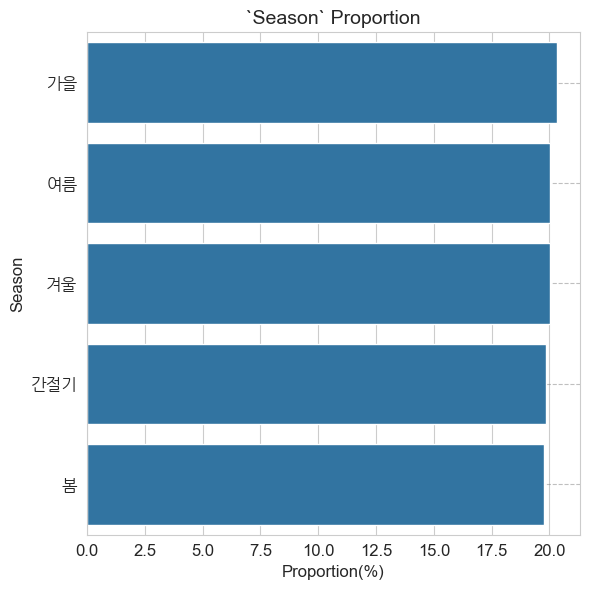

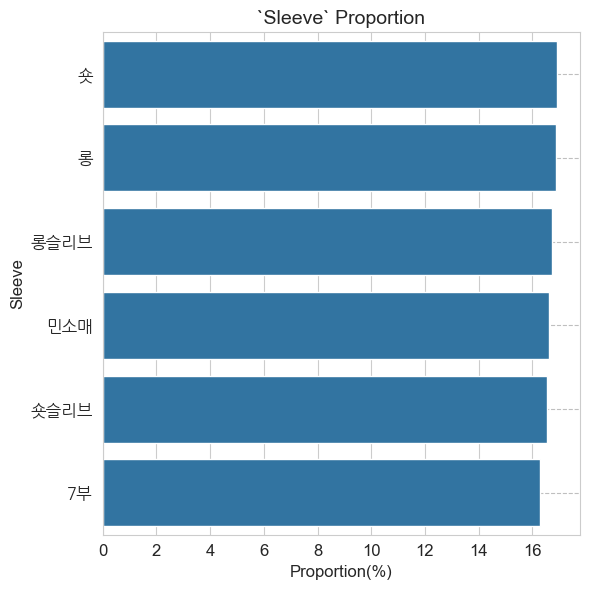

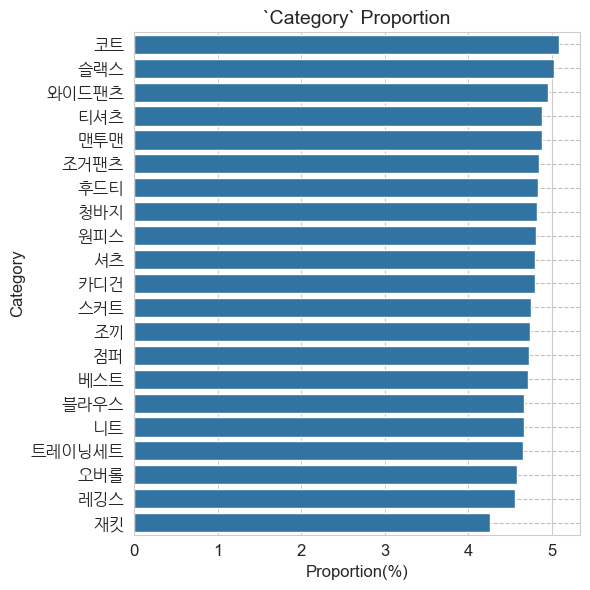

In [23]:
# 분류 속성별 필드값 분포 확인
for col in columns:
    # 속성별 비율 집계
    df_item[col].value_counts()
    df_agg = (
        df_item[col]
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        .reset_index()
    )
    df_agg[col] = df_agg[col].astype(str)
    df_agg["proportion"] = df_agg["proportion"] * 100

    plt.figure(figsize=(6, 6), dpi=100)
    sns.barplot(data=df_agg, x="proportion", y=col)
    plt.title(f"`{col.capitalize()}` Proportion", fontsize=14)
    plt.xlabel("Proportion(%)", fontsize=12)
    plt.ylabel(col.capitalize(), fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, fontproperties=fontprop)
    plt.grid(True, axis="y", linestyle="--", color="grey", alpha=0.5)
    plt.tight_layout()
    plt.show()

## Text Vector
- Vector Similarity Search 기반 추천을 위한 아이템 임베딩 벡터 생성

### SentenceTransformer

In [24]:
from sentence_transformers import SentenceTransformer

# -----------------------------------------------
# 1) 텍스트 임베딩 모델 불러오기 (영문 전용)
# -----------------------------------------------
# - "all-MiniLM-L6-v2": 소형 영문 문장 임베딩 모델
# - `normalize_embeddings=True`: 코사인 유사도를 위해 벡터를 정규화
model = SentenceTransformer("all-MiniLM-L6-v2")

# 아이템 제목(title)을 벡터로 변환
embeddings = model.encode(df_item["title"].tolist(), normalize_embeddings=True)
embeddings = np.array(embeddings).astype("float32")

# 원본 데이터프레임에 text_vector 컬럼 추가
df_item["text_vector"] = embeddings.tolist()

# FAISS 인덱스 생성 (내적 기반 유사도)
dim = embeddings.shape[1]
print(f"임베딩 차원: {dim}")
index = faiss.IndexFlatIP(dim)  # Inner Product (코사인 유사도용)
index.add(embeddings)


# -----------------------------------------------
# 2) 유사 아이템 검색 함수 (영문 모델 버전)
# -----------------------------------------------
def find_similar_items(query_text: str, top_k: int = 5):
    query_vec = model.encode([query_text], normalize_embeddings=True).astype("float32")
    scores, indices = index.search(query_vec, top_k)

    print(f"\n[🔍 입력 아이템 제목] {query_text}\n")
    print("[📌 유사한 아이템]")
    for rank, idx in enumerate(indices[0]):
        sim_score = scores[0][rank]
        print(f"{rank+1}. {df_item.iloc[idx]['title']} (score: {sim_score:.4f})")


# 예시 질의
find_similar_items("화이트 반팔 티셔츠")
find_similar_items("여름 린넨 원피스")

임베딩 차원: 384

[🔍 입력 아이템 제목] 화이트 반팔 티셔츠

[📌 유사한 아이템]
1. 겨울 오버핏 화이트 코튼 숏 원피스 (score: 0.8615)
2. 겨울 크롭핏 화이트 플리스 숏 조거팬츠 (score: 0.8554)
3. 가을 루즈핏 화이트 퍼 롱 오버롤 (score: 0.8534)
4. 가을 크롭핏 화이트 코튼 민소매 조거팬츠 (score: 0.8487)
5. 가을 슬림핏 화이트 모달 롱 베스트 (score: 0.8463)

[🔍 입력 아이템 제목] 여름 린넨 원피스

[📌 유사한 아이템]
1. 여름 감성 레귤러핏 린넨 원피스 (score: 0.9367)
2. 여름 감성 세미오버핏 린넨 원피스 (score: 0.9367)
3. 여름 감성 루즈핏 스웨이드 원피스 (score: 0.9318)
4. 여름 감성 레귤러핏 메쉬 원피스 (score: 0.9318)
5. 봄 세미오버핏 브라운 데님 숏슬리브 원피스 (score: 0.9264)


### e5-base

In [25]:
from sentence_transformers import SentenceTransformer
import faiss

# -----------------------------------------------
# 1) multilingual 임베딩 모델 (한국어 포함)
# -----------------------------------------------
# - "intfloat/multilingual-e5-base": 한국어 포함 다국어 임베딩 모델
# - E5 모델은 입력 프롬프트에 prefix 필요:
#   - "query: ..."  (검색 쿼리)
#   - "passage: ..." (코퍼스/문서)
model = SentenceTransformer("intfloat/multilingual-e5-base")

# 아이템 제목을 "passage" 형식으로 변환 후 임베딩
corpus_texts = ["passage: " + t for t in df_item["title"].tolist()]
embeddings = model.encode(corpus_texts, normalize_embeddings=True)
embeddings = np.array(embeddings).astype("float32")
df_item["text_vector"] = embeddings.tolist()

# FAISS 인덱스 생성 (내적 기반 유사도)
dim = embeddings.shape[1]
print(f"임베딩 차원: {dim}")
index = faiss.IndexFlatIP(dim)
index.add(embeddings)


# -----------------------------------------------
# 4) 유사 아이템 검색 함수 (multilingual 버전)
# -----------------------------------------------
def find_similar_items(query_text: str, top_k: int = 5):
    # 쿼리 입력 시 "query:" prefix를 붙여야 함
    query_vec = model.encode(
        ["query: " + query_text], normalize_embeddings=True
    ).astype("float32")
    scores, indices = index.search(query_vec, top_k)

    print(f"\n[🔍 입력 아이템 제목] {query_text}\n")
    print("[📌 유사한 아이템]")
    for rank, idx in enumerate(indices[0]):
        sim_score = scores[0][rank]
        print(f"{rank + 1}. {df_item.iloc[idx]['title']} (score: {sim_score:.4f})")


# 예시 질의
find_similar_items("화이트 반팔 티셔츠")
find_similar_items("여름 린넬 원피스")

임베딩 차원: 768

[🔍 입력 아이템 제목] 화이트 반팔 티셔츠

[📌 유사한 아이템]
1. 가을에 어울리는 화이트 티셔츠 (score: 0.8709)
2. 여름에 어울리는 화이트 티셔츠 (score: 0.8689)
3. 간절기에 어울리는 화이트 티셔츠 (score: 0.8687)
4. 겨울에 어울리는 화이트 티셔츠 (score: 0.8674)
5. 화이트 컬러의 스트리트 스타일 폴리 셔츠 (score: 0.8639)

[🔍 입력 아이템 제목] 여름 린넬 원피스

[📌 유사한 아이템]
1. 여름 한정 린넨 소재 화이트 원피스 (score: 0.8835)
2. 여름 한정 린넨 소재 블랙 원피스 (score: 0.8820)
3. 여름 감성 레귤러핏 린넨 원피스 (score: 0.8810)
4. 여름 감성 세미오버핏 린넨 원피스 (score: 0.8736)
5. 여름에 어울리는 레드 원피스 (score: 0.8724)


In [26]:
# 최종 저장 (텍스트 벡터는 별도로 저장)
df_text_vectors = df_item[["item_id", "text_vector"]]
df_text_vectors.to_parquet(paths.text_vectors_path)

## Image Vector
- Vector Similarity Search 기반 추천을 위한 아이템 임베딩 벡터 생성

In [27]:
# 생략

# Save

In [28]:
# 원본 메타데이터에서는 vector 컬럼 제거 후 저장
df_item.drop(columns=["text_vector"]).to_parquet(paths.item_metadata_path)